In [1]:
%load_ext autoreload
%autoreload 2
import os

import matplotlib.pyplot as plt
import torch
import torchdiffeq
import torchsde
from torchdyn.core import NeuralODE
from torchvision import datasets, transforms
from torchvision.transforms import ToPILImage
from torchvision.utils import make_grid
from tqdm import tqdm

from torchcfm.conditional_flow_matching import ConditionalFlowMatcher, ExactOptimalTransportConditionalFlowMatcher, SchrodingerBridgeConditionalFlowMatcher
from torchcfm.models.unet import UNetModel

savedir = "models/cond_mnist"
os.makedirs(savedir, exist_ok=True)

2025-05-08 14:54:31.015892: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-05-08 14:54:31.015964: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-05-08 14:54:31.031426: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-08 14:54:31.055947: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

2025-05-08 14:54:33.648744: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [2]:
use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
batch_size = 128
n_epochs = 10

trainset = datasets.MNIST(
    "../data",
    train=True,
    download=True,
    transform=transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))]),
)

train_loader = torch.utils.data.DataLoader(
    trainset, batch_size=batch_size, shuffle=True, drop_last=True
)

In [3]:
#################################
#    Float Conditional CFM
#################################

class embed_condition(torch.nn.Module):
    """ simple network to embed the condition, other architectures can be used too """

    def __init__(self, input_dim=1, target_dim = 128):
        super().__init__()

        self.model = torch.nn.Sequential(
            torch.nn.Linear(input_dim, target_dim),
            torch.nn.GELU(),
            torch.nn.Linear(target_dim, target_dim),
        )

    def forward(self, label):

        return self.model(label)



sigma = 0.0
model = UNetModel(
    dim=(1, 28, 28), num_channels=32, num_res_blocks=1, embedding_net=embed_condition
).to(device)
optimizer = torch.optim.Adam(model.parameters())
FM = ConditionalFlowMatcher(sigma=sigma)
# Users can try target FM by changing the above line by
# FM = TargetConditionalFlowMatcher(sigma=sigma)
node = NeuralODE(model, solver="dopri5", sensitivity="adjoint", atol=1e-4, rtol=1e-4)

In [4]:
for epoch in range(n_epochs):
    for i, data in enumerate(train_loader):
        optimizer.zero_grad()
        x1 = data[0].to(device)
        y = data[1].float().to(device).reshape((batch_size, 1)) / 2. #just to have a floating point label
        x0 = torch.randn_like(x1)
        t, xt, ut = FM.sample_location_and_conditional_flow(x0, x1)
        vt = model(t, xt, y)
        loss = torch.mean((vt - ut) ** 2)
        loss.backward()
        optimizer.step()
        print(f"cfm epoch: {epoch}, steps: {i}, loss: {loss.item():.4}", end="\r")

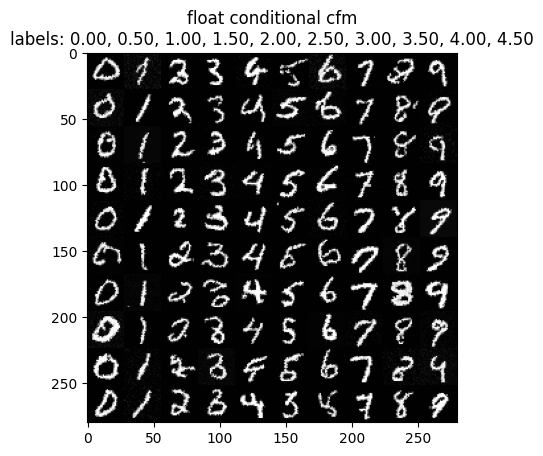

In [5]:
USE_TORCH_DIFFEQ = True
ntest = 10*10
generated_class_list = torch.arange(10, device=device).repeat(10).reshape((ntest, 1)).float() / 2. #TODO: reshape
with torch.no_grad():
    if USE_TORCH_DIFFEQ:
        traj = torchdiffeq.odeint(
            lambda t, x: model.forward(t, x, generated_class_list),
            torch.randn(100, 1, 28, 28, device=device),
            torch.linspace(0, 1, 2, device=device),
            atol=1e-4,
            rtol=1e-4,
            method="dopri5",
        )
    else:
        traj = node.trajectory(
            torch.randn(100, 1, 28, 28, device=device),
            t_span=torch.linspace(0, 1, 2, device=device),
        )
grid = make_grid(
    traj[-1, :100].view([-1, 1, 28, 28]).clip(-1, 1), value_range=(-1, 1), padding=0, nrow=10
)
img = ToPILImage()(grid)
plt.imshow(img)
cond_values = ", ".join([ f"{float(item):.2f}" for item in generated_class_list[0:10,0] ])
plt.title(f"float conditional cfm\nlabels: {cond_values}")
plt.savefig("floatconditional-cfm_noninteger.svg")

In [6]:
#################################
#            OT-CFM
#################################

sigma = 0.0
model = UNetModel(
    dim=(1, 28, 28), num_channels=32, num_res_blocks=1, embedding_net=embed_condition
).to(device)
optimizer = torch.optim.Adam(model.parameters())
FM = ExactOptimalTransportConditionalFlowMatcher(sigma=sigma)
node = NeuralODE(model, solver="dopri5", sensitivity="adjoint", atol=1e-4, rtol=1e-4)

In [7]:
for epoch in range(n_epochs):
    for i, data in enumerate(train_loader):
        optimizer.zero_grad()
        x1 = data[0].to(device)
        y = data[1].float().to(device).reshape((batch_size, 1)) / 2. #just to have a floating point label
        x0 = torch.randn_like(x1)
        t, xt, ut, _, y1 = FM.guided_sample_location_and_conditional_flow(x0, x1, y1=y)
        vt = model(t, xt, y1)
        loss = torch.mean((vt - ut) ** 2)
        loss.backward()
        optimizer.step()
        print(f"OT-CFM epoch: {epoch}, steps: {i}, loss: {loss.item():.4}", end="\r")

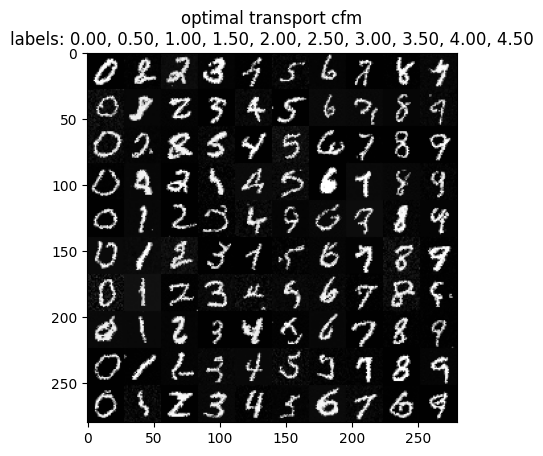

In [8]:
USE_TORCH_DIFFEQ = True
with torch.no_grad():
    if USE_TORCH_DIFFEQ:
        traj = torchdiffeq.odeint(
            lambda t, x: model.forward(t, x, generated_class_list),
            torch.randn(100, 1, 28, 28, device=device),
            torch.linspace(0, 1, 2, device=device),
            atol=1e-4,
            rtol=1e-4,
            method="dopri5",
        )
    else:
        traj = node.trajectory(
            torch.randn(100, 1, 28, 28, device=device),
            t_span=torch.linspace(0, 1, 2, device=device),
        )
grid = make_grid(
    traj[-1, :100].view([-1, 1, 28, 28]).clip(-1, 1), value_range=(-1, 1), padding=0, nrow=10
)
img = ToPILImage()(grid)
plt.imshow(img)
plt.title(f"optimal transport cfm\nlabels: {cond_values}")
plt.savefig("ot-cfm_noninteger.svg")

In [9]:
#################################
#            SF2M
#################################
batch_size = 128
n_epochs = 10
sigma = 0.1


model = UNetModel(
    dim=(1, 28, 28), num_channels=32, num_res_blocks=1, embedding_net=embed_condition
).to(device)
score_model = UNetModel(
    dim=(1, 28, 28), num_channels=32, num_res_blocks=1, embedding_net=embed_condition
).to(device)

optimizer = torch.optim.Adam(list(model.parameters()) + list(score_model.parameters()))
FM = SchrodingerBridgeConditionalFlowMatcher(sigma=sigma)
node = NeuralODE(model, solver="dopri5", sensitivity="adjoint", atol=1e-4, rtol=1e-4)

In [10]:
for epoch in range(n_epochs):
    for i, data in tqdm(enumerate(train_loader)):
        optimizer.zero_grad()
        x1 = data[0].to(device)
        y = data[1].float().to(device).reshape((batch_size, 1)) / 2. #just to have a floating point label
        x0 = torch.randn_like(x1)
        t, xt, ut, _, y1, eps = FM.guided_sample_location_and_conditional_flow(
            x0, x1, y1=y, return_noise=True
        )
        lambda_t = FM.compute_lambda(t)
        vt = model(t, xt, y1)
        st = score_model(t, xt, y1)
        flow_loss = torch.mean((vt - ut) ** 2)
        score_loss = torch.mean((lambda_t[:, None, None, None] * st + eps) ** 2)
        loss = flow_loss + score_loss
        loss.backward()
        optimizer.step()
        print(f"SF2M epoch: {epoch}, steps: {i}, loss: {loss.item():.4}", end="\r")

0it [00:00, ?it/s]

1it [00:00,  8.16it/s]

2it [00:00,  8.54it/s]

3it [00:00,  8.71it/s]

4it [00:00,  8.79it/s]

...

465it [00:52,  8.94it/s]

466it [00:52,  8.94it/s]

467it [00:52,  8.93it/s]

468it [00:52,  8.93it/s]

468it [00:52,  8.93it/s]

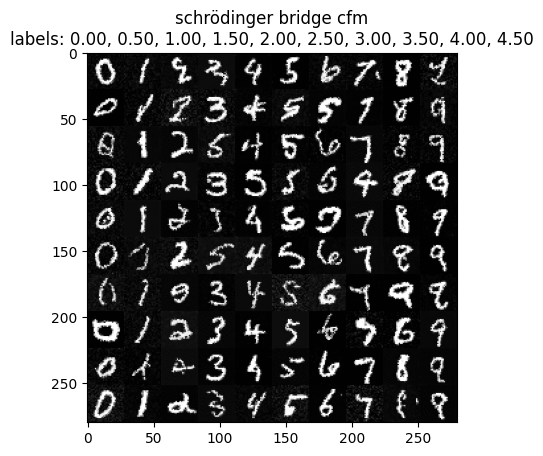

In [11]:
USE_TORCH_DIFFEQ = True

node = NeuralODE(model, solver="euler", sensitivity="adjoint", atol=1e-4, rtol=1e-4)
# Evaluate the ODE
with torch.no_grad():
    if USE_TORCH_DIFFEQ:
        traj = torchdiffeq.odeint(
            lambda t, x: model.forward(t, x, generated_class_list),
            torch.randn(100, 1, 28, 28, device=device),
            torch.linspace(0, 1, 2, device=device),
            atol=1e-4,
            rtol=1e-4,
            method="dopri5",
        )
    else:
        traj = node.trajectory(
            torch.randn(100, 1, 28, 28, device=device),
            t_span=torch.linspace(0, 1, 2, device=device),
        )
grid = make_grid(
    traj[-1, :100].view([-1, 1, 28, 28]).clip(-1, 1), value_range=(-1, 1), padding=0, nrow=10
)
img = ToPILImage()(grid)
plt.imshow(img)
plt.title(f"schrödinger bridge cfm\nlabels: {cond_values}")
plt.savefig("sf2m_noninteger.svg")

In [12]:
# follows example from https://github.com/google-research/torchsde/blob/master/examples/cont_ddpm.py


# class SDE(torch.nn.Module):
#     noise_type = "diagonal"
#     sde_type = "ito"

#     def __init__(self, ode_drift, score, labels=None, reverse=False, sigma=0.1):
#         super().__init__()
#         self.drift = ode_drift
#         self.score = score
#         self.reverse = reverse
#         self.labels = labels
#         self.sigma = sigma

#     # Drift

#     def f(self, t, y):
#         y = y.view(-1, 1, 28, 28)
#         if self.reverse:
#             t = 1 - t
#             return -self.drift(t, y, self.labels) + self.score(t, y, self.labels)
#         return self.drift(t, y, self.labels).flatten(start_dim=1) + self.score(
#             t, y, self.labels
#         ).flatten(start_dim=1)

#     # Diffusion
#     def g(self, t, y):
#         return torch.ones_like(y) * self.sigma


# # %%
# sde = SDE(model, score_model, labels=torch.arange(10, device=device).repeat(10), sigma=0.1)
# with torch.no_grad():
#     sde_traj = torchsde.sdeint(
#         sde,
#         # x0.view(x0.size(0), -1),
#         torch.randn(100, 1 * 28 * 28, device=device),
#         ts=torch.linspace(0, 1, 2, device=device),
#         dt=0.01,
#     )

# # %%
# grid = make_grid(
#     sde_traj[-1, :100].view([-1, 1, 28, 28]).clip(-1, 1), value_range=(-1, 1), padding=0, nrow=10
# )
# img = ToPILImage()(grid)
# plt.imshow(img)